# Vietnamese VQA — Model A
**Kiến trúc:**
- **A1** ResNet50 + PhoBERT → LSTM Decoder + Bahdanau Attention (49 vùng không gian)
- **A2** ResNet50 + PhoBERT → Transformer Decoder (3 lớp, 8 heads)

## Outline

| Section | Mô tả |
|---|---|
| 1. Setup | Imports, paths, data loading |
| 2. Kiến trúc | ResNet50 image encoder + PhoBERT text encoder + 2 decoders (A1 LSTM, A2 Transformer) |
| 3. Training | CrossEntropy + label-smoothing, AMP, scheduler |
| 4. Inference | Beam search decoding |
| 5. Evaluation | EM, soft acc, BLEU, ROUGE-L, METEOR, BERTScore, semantic sim |
| 6. LLM-as-a-Judge | Claude API (mặc định tắt) |
| 7. Validation & Test eval | Chạy A1 + A2 trên cả 2 split |
| 8. Kết quả | Bảng tổng hợp + persist `results/results_A.json` cho VQA_Demo_Compare |

**4 cấu hình bắt buộc** của hướng A (so sánh decoder, giữ nguyên image+text encoder):
- **A1**: ResNet50 + PhoBERT + **LSTM** decoder + Bahdanau attention (49 spatial regions)
- **A2**: ResNet50 + PhoBERT + **Transformer** decoder (3 layers, 8 heads)


In [2]:
!pip install -q -U \
    transformers accelerate tokenizers safetensors huggingface_hub sentencepiece \
    nltk rouge-score bert-score sentence-transformers anthropic


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 100.9 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.1/763.1 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 107.3 MB/s eta 0:00:0000:01


## 1. Setup


In [3]:
import os, re, json, math, gc, platform, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

import nltk
for _pkg in ["wordnet", "punkt", "omw-1.4"]:
    nltk.download(_pkg, quiet=True)

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0 if platform.system() == "Windows" else 4

def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Device: {device} | Workers: {NUM_WORKERS}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | VRAM: {p.total_memory/1024**3:.1f} GB")


Device: cuda | Workers: 4
GPU: Tesla T4 | VRAM: 14.6 GB


In [4]:
# ── Auto-detect Kaggle / local ─────────────────────────────────────────────
KAGGLE = Path("/kaggle").exists()
if KAGGLE:
    # Chỉnh slug cho khớp tên Kaggle Dataset của bạn
    INPUT_ROOT = Path("/kaggle/input/datasets/gialacteddy/vqa-food-dataset")
    WORK_ROOT  = Path("/kaggle/working")
else:
    INPUT_ROOT = Path("data")
    WORK_ROOT  = Path(".")

IMG_DIR    = str(INPUT_ROOT / "images")
TRAIN_JSON = str(INPUT_ROOT / "annotations" / "train.json")
VAL_JSON   = str(INPUT_ROOT / "annotations" / "val.json")
TEST_JSON  = str(INPUT_ROOT / "annotations" / "test.json")

CKPT_DIR    = WORK_ROOT / "checkpoints"
RESULTS_DIR = WORK_ROOT / "results"
FIG_DIR     = WORK_ROOT / "figures"
for d in [CKPT_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Training hyperparameters ────────────────────────────────────────────────
EPOCHS     = 10
LR         = 1e-4
BATCH_SIZE = 32
MAX_LEN_A  = 12

# ── ImageNet normalisation (shared by Dataset & inference) ──────────────────
_IMG_MEAN = [0.485, 0.456, 0.406]
_IMG_STD  = [0.229, 0.224, 0.225]

_TF_TRAIN = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(_IMG_MEAN, _IMG_STD),
])

_TF_EVAL = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(_IMG_MEAN, _IMG_STD),
])

def load_image(item, img_dir=IMG_DIR):
    """Mở ảnh RGB; trả về ảnh trắng 224x224 nếu lỗi."""
    path = item["image"]
    if img_dir and not os.path.isabs(path):
        path = os.path.join(img_dir, path)
    try:
        return Image.open(path).convert("RGB")
    except Exception as exc:
        print(f"[WARN] Cannot open {path}: {exc}")
        return Image.new("RGB", (224, 224))

print(f"Kaggle      : {KAGGLE}")
print(f"Input root  : {INPUT_ROOT}")
print(f"Work root   : {WORK_ROOT}")
print(f"Ckpt dir    : {CKPT_DIR}")


Kaggle      : True
Input root  : /kaggle/input/datasets/gialacteddy/vqa-food-dataset
Work root   : /kaggle/working
Ckpt dir    : /kaggle/working/checkpoints


In [5]:
with open(TRAIN_JSON, encoding="utf-8") as f:
    train_data = json.load(f)
with open(VAL_JSON, encoding="utf-8") as f:
    val_data = json.load(f)

if os.path.exists(TEST_JSON):
    with open(TEST_JSON, encoding="utf-8") as f:
        test_data = json.load(f)
    print(f"Test : {len(test_data):,} (riêng biệt)")
else:
    split = int(len(val_data) * 0.8)
    test_data = val_data[split:]
    val_data  = val_data[:split]
    print(f"[INFO] Không có test.json → chia val 80/20")

print(f"Train: {len(train_data):,} | Val: {len(val_data):,} | Test: {len(test_data):,}")
print(f"Sample: {train_data[0]}")

Test : 1,172 (riêng biệt)
Train: 9,277 | Val: 1,178 | Test: 1,172
Sample: {'image': 'train/banh_mi_thit/Image_18.jpg', 'question': 'Hãy cho mình biết, món ăn này phổ biến ở miền nào?', 'answer': 'nam', 'type': 'attribute'}


In [6]:
def tokenize(text: str) -> list:
    """Lowercase, strip punctuation, whitespace-split."""
    return re.sub(r"[^\w\s]", "", text.lower().strip()).split()

def token_f1(pred: str, gt: str) -> float:
    """Bag-of-words token-level F1."""
    pc, gc_ = Counter(tokenize(pred)), Counter(tokenize(gt))
    common = sum((pc & gc_).values())
    if common == 0:
        return 0.0
    p = common / max(sum(pc.values()), 1)
    r = common / max(sum(gc_.values()), 1)
    return 2 * p * r / (p + r)

def build_vocab(data, min_freq: int = 2):
    counter = Counter()
    for d in data:
        counter.update(tokenize(d["answer"]))
    vocab = ["<pad>", "<bos>", "<eos>", "<unk>"]
    for w, c in counter.most_common():
        if c >= min_freq:
            vocab.append(w)
    w2i = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in w2i.items()}
    print(f"Vocab: {len(vocab):,} words (min_freq={min_freq})")
    return w2i, i2w

w2i, i2w = build_vocab(train_data)
PAD, BOS, EOS, UNK = w2i["<pad>"], w2i["<bos>"], w2i["<eos>"], w2i["<unk>"]
vocab_size = len(w2i)


Vocab: 64 words (min_freq=2)


In [7]:
class VQADataset(Dataset):
    def __init__(self, data, img_dir=None, max_len_a=MAX_LEN_A, training=False):
        self.data = data
        self.img_dir = img_dir
        self.max_len_a = max_len_a
        self.tf = _TF_TRAIN if training else _TF_EVAL

    def _encode(self, ans):
        ids = [BOS] + [w2i.get(t, UNK) for t in tokenize(ans)]
        ids = ids[:self.max_len_a - 1] + [EOS]
        ids += [PAD] * (self.max_len_a - len(ids))
        return torch.tensor(ids[:self.max_len_a], dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            "image"   : self.tf(load_image(item, self.img_dir)),
            "question": item["question"],
            "answer"  : self._encode(item["answer"]),
            "gt_text" : item["answer"],
        }


In [8]:
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def collate_fn(batch):
    enc = tokenizer(
        [b["question"] for b in batch],
        padding=True, truncation=True, max_length=64, return_tensors="pt",
    )
    return {
        "image"         : torch.stack([b["image"]  for b in batch]),
        "input_ids"     : enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "answer"        : torch.stack([b["answer"] for b in batch]),
        "gt_texts"      : [b["gt_text"] for b in batch],
    }

# Train DS: bật augmentation (random crop + flip + color jitter).
# Val DS: deterministic transform (no augment) để metric stable.
train_loader = DataLoader(VQADataset(train_data, IMG_DIR, training=True),  BATCH_SIZE,
    shuffle=True,  num_workers=NUM_WORKERS, pin_memory=NUM_WORKERS > 0, collate_fn=collate_fn)
val_loader   = DataLoader(VQADataset(val_data,   IMG_DIR, training=False), BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=NUM_WORKERS > 0, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 290 | Val batches: 37


## 2. Kiến trúc Model


In [9]:
class ImageEncoder(nn.Module):
    """ResNet-50 backbone (frozen) → (B, 49, 512) spatial feature map."""
    def __init__(self, out_dim=512):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.proj = nn.Sequential(
            nn.Conv2d(2048, out_dim, 1),
            nn.BatchNorm2d(out_dim),
            nn.ReLU(inplace=True),
        )
        for p in self.backbone.parameters():
            p.requires_grad = False

    def forward(self, x):
        x = self.proj(self.backbone(x))                # (B,512,7,7)
        B, C, H, W = x.shape
        return x.view(B, C, H * W).permute(0, 2, 1)    # (B,49,512)


class BahdanauAttention(nn.Module):
    """Additive attention over N spatial regions."""
    def __init__(self, d=512):
        super().__init__()
        self.W = nn.Linear(d, d, bias=False)
        self.U = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, 1, bias=False)

    def forward(self, features, hidden):
        e = torch.tanh(self.W(features) + self.U(hidden).unsqueeze(1))
        a = torch.softmax(self.v(e).squeeze(-1), dim=1)
        return (features * a.unsqueeze(-1)).sum(1), a


class PositionalEncoding(nn.Module):
    def __init__(self, d=512, maxlen=128, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(maxlen, d)
        pos = torch.arange(0, maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class TrfDecoder(nn.Module):
    def __init__(self, vocab_size, d=512, nhead=8, layers=3, dropout=0.1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d, padding_idx=PAD)
        self.pos = PositionalEncoding(d, dropout=dropout)
        layer = nn.TransformerDecoderLayer(
            d_model=d, nhead=nhead,
            dim_feedforward=d * 4, dropout=dropout, batch_first=True,
        )
        self.dec = nn.TransformerDecoder(layer, num_layers=layers)
        self.fc  = nn.Linear(d, vocab_size)

    def forward(self, memory, captions):
        tgt = self.pos(self.emb(captions))
        sz  = tgt.size(1)
        mask = torch.triu(torch.full((sz, sz), float("-inf"), device=tgt.device), 1)
        return self.fc(self.dec(tgt=tgt, memory=memory, tgt_mask=mask))


class MultimodalFusion(nn.Module):
    def __init__(self, d=512, dropout=0.1):
        super().__init__()
        self.fc   = nn.Linear(d, d)
        self.drop = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d)

    def forward(self, img, txt):
        return self.norm(self.drop(self.fc(img + txt.unsqueeze(1))))


class VQAModelA1(nn.Module):
    """LSTM Decoder + Bahdanau Attention over 49 image regions."""
    def __init__(self, vocab_size, d=512, emb_dim=256):
        super().__init__()
        self.img_enc   = ImageEncoder(d)
        self.txt_enc   = AutoModel.from_pretrained("vinai/phobert-base", use_safetensors=True)
        for p in self.txt_enc.parameters():
            p.requires_grad = False
        self.txt_proj  = nn.Sequential(nn.Linear(768, d), nn.LayerNorm(d), nn.Dropout(0.1))
        self.fusion    = nn.Sequential(nn.Linear(d * 2, d), nn.Tanh())
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.attn      = BahdanauAttention(d)
        self.lstm      = nn.LSTMCell(emb_dim + d, d)
        self.drop      = nn.Dropout(0.3)
        self.fc        = nn.Linear(d, vocab_size)

    def encode(self, image, input_ids, attention_mask):
        img = self.img_enc(image)
        with torch.no_grad():
            out = self.txt_enc(input_ids=input_ids, attention_mask=attention_mask)
        txt = self.txt_proj(out.last_hidden_state[:, 0])
        return img, txt

    def forward(self, image, input_ids, attention_mask, captions):
        img, txt = self.encode(image, input_ids, attention_mask)
        h = self.fusion(torch.cat([img.mean(1), txt], 1))
        c = torch.zeros_like(h)
        outputs = []
        for t in range(captions.shape[1] - 1):
            emb     = self.embedding(captions[:, t])
            ctx, _  = self.attn(img, h)
            h, c    = self.lstm(torch.cat([emb, ctx], 1), (h, c))
            outputs.append(self.fc(self.drop(h)))
        return torch.stack(outputs, 1)


class VQAModelA2(nn.Module):
    """Transformer Decoder cross-attending fused image-text memory."""
    def __init__(self, vocab_size, d=512):
        super().__init__()
        self.img_enc  = ImageEncoder(d)
        self.txt_enc  = AutoModel.from_pretrained("vinai/phobert-base", use_safetensors=True)
        for p in self.txt_enc.parameters():
            p.requires_grad = False
        self.txt_proj = nn.Sequential(nn.Linear(768, d), nn.LayerNorm(d), nn.Dropout(0.1))
        self.fusion   = MultimodalFusion(d)
        self.decoder  = TrfDecoder(vocab_size, d)

    def encode(self, image, input_ids, attention_mask):
        img = self.img_enc(image)
        with torch.no_grad():
            out = self.txt_enc(input_ids=input_ids, attention_mask=attention_mask)
        txt = self.txt_proj(out.last_hidden_state[:, 0])
        return self.fusion(img, txt)

    def forward(self, image, input_ids, attention_mask, answer):
        return self.decoder(self.encode(image, input_ids, attention_mask), answer[:, :-1])


print("Architecture defined: A1 (LSTM+Attn), A2 (Transformer)")


Architecture defined: A1 (LSTM+Attn), A2 (Transformer)


## 3. Training


In [10]:
criterion  = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)

model_A1   = VQAModelA1(vocab_size).to(device)
model_A2   = VQAModelA2(vocab_size).to(device)

opt_A1 = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_A1.parameters()), lr=LR, weight_decay=1e-4)
opt_A2 = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_A2.parameters()), lr=LR, weight_decay=1e-4)

sch_A1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_A1, T_max=EPOCHS, eta_min=1e-6)
sch_A2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_A2, T_max=EPOCHS, eta_min=1e-6)

scaler_A1 = torch.amp.GradScaler("cuda")
scaler_A2 = torch.amp.GradScaler("cuda")

history = {"A1":{"train":[],"val":[]},"A2":{"train":[],"val":[]}}

for name, model in [("A1",model_A1),("A2",model_A2)]:
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model {name}: {n:,} trainable parameters")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s] 


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model A1: 5,169,216 trainable parameters
Model A2: 14,386,240 trainable parameters


In [11]:
def run_epoch(model, loader, optimizer=None, scaler=None, tag=""):
    training = optimizer is not None
    model.train() if training else model.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=f"[{tag}]", leave=False)
        for batch in pbar:
            img  = batch["image"].to(device, non_blocking=True)
            iid  = batch["input_ids"].to(device, non_blocking=True)
            am   = batch["attention_mask"].to(device, non_blocking=True)
            ans  = batch["answer"].to(device, non_blocking=True)
            with torch.amp.autocast("cuda"):
                out  = model(img, iid, am, ans)
                loss = criterion(out.reshape(-1, vocab_size), ans[:, 1:].reshape(-1))
            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            total += loss.item(); n += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total / n

best = {"A1": float("inf"), "A2": float("inf")}

for epoch in range(EPOCHS):
    print(f"{'='*52} Epoch {epoch+1:02d}/{EPOCHS} {'='*52}")
    for name, model, opt, sch, scaler in [
        ("A1", model_A1, opt_A1, sch_A1, scaler_A1),
        ("A2", model_A2, opt_A2, sch_A2, scaler_A2),
    ]:
        tr = run_epoch(model, train_loader, opt, scaler, f"{name} Train")
        vl = run_epoch(model, val_loader,   tag=f"{name} Val")
        sch.step()
        history[name]["train"].append(tr)
        history[name]["val"].append(vl)
        if vl < best[name]:
            best[name] = vl
            torch.save(model.state_dict(), CKPT_DIR / f"best_model_{name}.pth")
            print(f"  ✓ {name} saved → {CKPT_DIR}/best_model_{name}.pth (val_loss={vl:.4f})")
        print(f"  {name}: train={tr:.4f} val={vl:.4f} lr={sch.get_last_lr()[0]:.2e}")

print(f"\nBest val loss → A1: {best['A1']:.4f} | A2: {best['A2']:.4f}")


==================================================== Epoch 01/10 ====================================================


  ✓ A1 saved → /kaggle/working/checkpoints/best_model_A1.pth (val_loss=1.4597)
  A1: train=2.1772 val=1.4597 lr=9.76e-05


  ✓ A2 saved → /kaggle/working/checkpoints/best_model_A2.pth (val_loss=1.1256)
  A2: train=1.4789 val=1.1256 lr=9.76e-05
==================================================== Epoch 02/10 ====================================================


  ✓ A1 saved → /kaggle/working/checkpoints/best_model_A1.pth (val_loss=1.1871)
  A1: train=1.2919 val=1.1871 lr=9.05e-05


  ✓ A2 saved → /kaggle/working/checkpoints/best_model_A2.pth (val_loss=1.0469)
  A2: train=1.0525 val=1.0469 lr=9.05e-05
==================================================== Epoch 03/10 ====================================================


...

  ✓ A2 saved → /kaggle/working/checkpoints/best_model_A2.pth (val_loss=0.9246)
  A2: train=0.8232 val=0.9246 lr=1.05e-05
==================================================== Epoch 09/10 ====================================================


  ✓ A1 saved → /kaggle/working/checkpoints/best_model_A1.pth (val_loss=0.9943)
  A1: train=0.8945 val=0.9943 lr=3.42e-06


  A2: train=0.8166 val=0.9286 lr=3.42e-06
==================================================== Epoch 10/10 ====================================================


  A1: train=0.8941 val=0.9997 lr=1.00e-06


  ✓ A2 saved → /kaggle/working/checkpoints/best_model_A2.pth (val_loss=0.9150)
  A2: train=0.8132 val=0.9150 lr=1.00e-06

Best val loss → A1: 0.9943 | A2: 0.9150


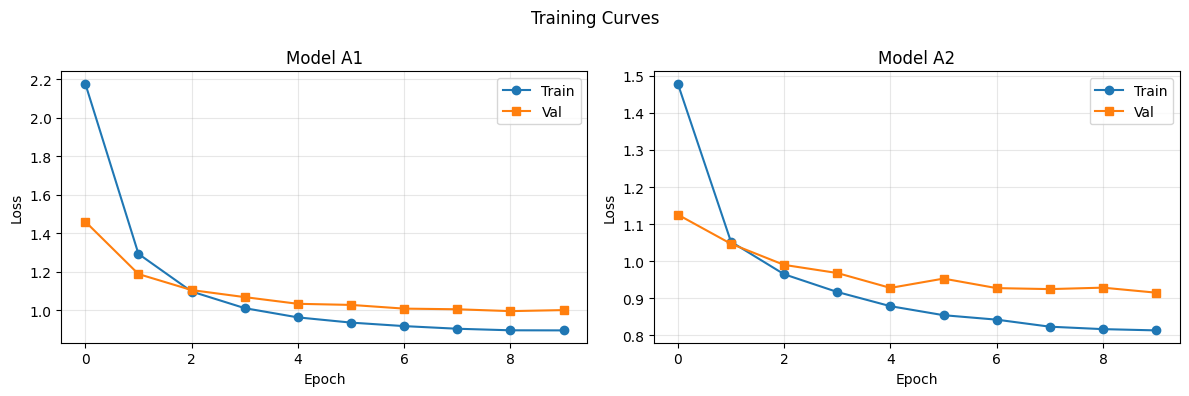

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["A1", "A2"]):
    ax.plot(history[name]["train"], marker="o", label="Train")
    ax.plot(history[name]["val"],   marker="s", label="Val")
    ax.set_title(f"Model {name}"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Training Curves"); plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves_A.png", dpi=150, bbox_inches="tight"); plt.show()


## 4. Load Best Checkpoints


In [13]:
model_A1.load_state_dict(torch.load(CKPT_DIR / "best_model_A1.pth",
                                    map_location=device, weights_only=True))
model_A2.load_state_dict(torch.load(CKPT_DIR / "best_model_A2.pth",
                                    map_location=device, weights_only=True))
model_A1.eval(); model_A2.eval()
print(f"✓ Best models loaded from {CKPT_DIR}")


✓ Best models loaded from /kaggle/working/checkpoints


## 5. Inference — Beam Search


In [14]:
# ── Beam search hyperparameters ─────────────────────────────────────────────
DECODE_MAX   = 10
DECODE_MIN   = 3
DECODE_BEAMS = 5
DECODE_ALPHA = 0.7
DECODE_NGR   = 2


def _safe_token(t):
    """Clamp về [0, vocab_size-1] để bảo vệ embedding khỏi token vượt vocab."""
    return max(0, min(int(t), vocab_size - 1))


def _block_ngrams(toks, logits, n):
    if n <= 0 or len(toks) < n - 1:
        return logits
    suf = tuple(toks[-(n - 1):])
    for s in range(len(toks) - (n - 1)):
        if tuple(toks[s:s + n - 1]) == suf:
            nxt = toks[s + n - 1]
            if 0 <= nxt < logits.size(0):
                logits[nxt] = float("-inf")
    return logits


def _beam(logits_fn, init_state):
    beams = [(0.0, [], init_state)]
    done = []
    for _ in range(DECODE_MAX):
        cands = []
        for lp, toks, state in beams:
            logits, new_state = logits_fn(toks, state)
            logits = logits.view(-1)[:vocab_size]

            if len(toks) < DECODE_MIN and 0 <= EOS < logits.size(0):
                logits[EOS] = float("-inf")

            logits = _block_ngrams(toks, logits, DECODE_NGR)
            lprob = torch.log_softmax(logits, dim=-1)
            topv, topi = torch.topk(lprob, DECODE_BEAMS)

            for tid, tlp in zip(topi.tolist(), topv.tolist()):
                tid = _safe_token(tid)
                ns = lp + tlp
                if tid == EOS:
                    n = max(len(toks), 1)
                    done.append((ns / (n ** DECODE_ALPHA), toks))
                else:
                    cands.append((ns, toks + [tid], new_state))
        if not cands:
            break
        cands.sort(key=lambda x: x[0], reverse=True)
        beams = cands[:DECODE_BEAMS]

    if not done:
        for lp, toks, _ in beams:
            done.append((lp / (max(len(toks), 1) ** DECODE_ALPHA), toks))
    done.sort(key=lambda x: x[0], reverse=True)
    return done[0][1] if done else []


def _decode_tokens(toks):
    """Token ids → list từ, dừng ở EOS."""
    words = []
    for t in toks:
        t = _safe_token(t)
        if t == EOS:
            break
        words.append(i2w.get(t, "<unk>"))
    return " ".join(words)


@torch.no_grad()
def generate_a1(model, item):
    model.eval()
    img = _TF_EVAL(load_image(item, IMG_DIR)).unsqueeze(0).to(device)
    enc = tokenizer(item["question"], return_tensors="pt", truncation=True, max_length=64)
    input_ids = enc["input_ids"].long().to(device)
    attn_mask = enc["attention_mask"].long().to(device)

    img_feat, txt_feat = model.encode(img, input_ids, attn_mask)
    h0 = model.fusion(torch.cat([img_feat.mean(1), txt_feat], dim=1))
    c0 = torch.zeros_like(h0)

    def step(toks, state):
        h, c = state
        last_tok = BOS if not toks else _safe_token(toks[-1])
        w = torch.tensor([last_tok], dtype=torch.long, device=device)
        emb = model.embedding(w)
        ctx, _ = model.attn(img_feat, h)
        h, c = model.lstm(torch.cat([emb, ctx], dim=1), (h, c))
        return model.fc(h).squeeze(0), (h, c)

    return _decode_tokens(_beam(step, (h0, c0)))


@torch.no_grad()
def generate_a2(model, item):
    model.eval()
    img = _TF_EVAL(load_image(item, IMG_DIR)).unsqueeze(0).to(device)
    enc = tokenizer(item["question"], return_tensors="pt", truncation=True, max_length=64)
    input_ids = enc["input_ids"].long().to(device)
    attn_mask = enc["attention_mask"].long().to(device)

    mem = model.encode(img, input_ids, attn_mask)

    def step(toks, _state):
        seq = [BOS] + [_safe_token(t) for t in toks]
        inp = torch.tensor(seq, dtype=torch.long, device=device).unsqueeze(0)
        return model.decoder(mem, inp)[0, -1], None

    return _decode_tokens(_beam(step, None))


print("Beam-search generators ready.")


Beam-search generators ready.


## 6. Evaluation Metrics


In [15]:
from nltk.translate.bleu_score   import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as _meteor
from rouge_score                 import rouge_scorer as _rouge_lib
from bert_score                  import score as _bscore
from sentence_transformers       import SentenceTransformer, util as _st

_SMOOTH  = SmoothingFunction().method1
_ROUGE   = _rouge_lib.RougeScorer(["rougeL"], use_stemmer=False)
_SEMODEL = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")


def exact_match(preds, gts):
    return sum(p.strip().lower() == g.strip().lower() for p, g in zip(preds, gts)) / len(preds)


def soft_accuracy(preds, gts):
    return sum(token_f1(p, g) for p, g in zip(preds, gts)) / len(preds)


def compute_ngram(preds, gts):
    b1, b2, mt, rl = [], [], [], []
    for p, g in zip(preds, gts):
        ref, hyp = tokenize(g), tokenize(p)
        b1.append(sentence_bleu([ref], hyp, weights=(1, 0, 0, 0), smoothing_function=_SMOOTH))
        b2.append(sentence_bleu([ref], hyp, weights=(.5, .5, 0, 0), smoothing_function=_SMOOTH))
        mt.append(_meteor([ref], hyp))
        rl.append(_ROUGE.score(g, p)["rougeL"].fmeasure)
    mean = lambda xs: sum(xs) / len(xs)
    return {"BLEU-1": mean(b1), "BLEU-2": mean(b2), "METEOR": mean(mt), "ROUGE-L": mean(rl)}


def compute_bertscore(preds, gts, lang="vi"):
    _, _, F1 = _bscore(preds, gts, lang=lang, verbose=False)
    return F1.mean().item()


def compute_semsim(preds, gts, max_n=300):
    ep = _SEMODEL.encode(preds[:max_n], convert_to_tensor=True, batch_size=32)
    eg = _SEMODEL.encode(gts[:max_n],   convert_to_tensor=True, batch_size=32)
    return _st.cos_sim(ep, eg).diagonal().mean().item()


def full_eval(preds, gts, tag=""):
    print(f"\n── Eval [{tag}] ─────────────────────────────")
    out = {"Exact Match": exact_match(preds, gts), "Token F1 (Soft)": soft_accuracy(preds, gts)}
    out.update(compute_ngram(preds, gts))
    out["BERTScore F1"] = compute_bertscore(preds, gts)
    out["Semantic Sim"] = compute_semsim(preds, gts)
    out["LLM Judge"]    = None
    for k, v in out.items():
        s = f"{v:.4f}" if v is not None else "(not run)"
        print(f"   {k:<22}: {s}")
    return out


# Shared display config (used by results table + plots)
METRICS = ["Exact Match", "Token F1 (Soft)", "BLEU-1", "BLEU-2",
           "METEOR", "ROUGE-L", "BERTScore F1", "Semantic Sim"]
COLORS  = {"A1 Val": "#4A90D9", "A1 Test": "#185FA5",
           "A2 Val": "#72C472", "A2 Test": "#3B6D11"}

print("Metrics ready.")


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Metrics ready.


## 7. LLM-as-a-Judge

> Bật: `USE_LLM_JUDGE = True` + `export ANTHROPIC_API_KEY=sk-ant-...`


In [16]:
# LLM-as-a-Judge using Claude. Trên Kaggle: add secret ANTHROPIC_API_KEY
# qua Add-ons → Secrets. Trên local: export ANTHROPIC_API_KEY env var.
USE_LLM_JUDGE = True
LLM_N         = 50

if KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        os.environ.setdefault("ANTHROPIC_API_KEY",
                              UserSecretsClient().get_secret("ANTHROPIC_API_KEY"))
    except Exception as exc:
        print(f"[WARN] Không load được Kaggle secret ANTHROPIC_API_KEY: {exc}")

try:
    import anthropic
    _ANTHROPIC_OK = True
except ImportError:
    _ANTHROPIC_OK = False

_JUDGE_PROMPT = (
    "Bạn là giám khảo VQA tiếng Việt.\n"
    "Câu hỏi: {q}\n"
    "Đáp án đúng: {gt}\n"
    "Dự đoán: {pred}\n\n"
    "Chấm độ chính xác từ 0 (sai hoàn toàn) đến 10 (đúng tuyệt đối).\n"
    'Chỉ trả về JSON đúng dạng: {{"score": <số>, "reason": "<1 câu>"}}.\n'
    "Không markdown, không text thêm."
)


def run_llm_judge(preds, gts, qs, n=LLM_N, tag=""):
    if not USE_LLM_JUDGE:
        return None
    if not _ANTHROPIC_OK:
        print("[WARN] anthropic chưa cài — bỏ qua LLM judge.")
        return None
    api_key = os.environ.get("ANTHROPIC_API_KEY", "")
    if not api_key:
        print("[WARN] ANTHROPIC_API_KEY chưa set — bỏ qua LLM judge.")
        return None
    client = anthropic.Anthropic(api_key=api_key)
    scores = []
    for p, g, q in tqdm(zip(preds[:n], gts[:n], qs[:n]),
                        total=min(n, len(preds)), desc=f"Judge[{tag}]"):
        try:
            msg = client.messages.create(
                model="claude-sonnet-4-20250514", max_tokens=120,
                messages=[{"role": "user",
                           "content": _JUDGE_PROMPT.format(q=q, gt=g, pred=p)}],
            )
            raw = msg.content[0].text.strip().replace("```json", "").replace("```", "").strip()
            scores.append(float(json.loads(raw).get("score", 0)))
        except Exception as exc:
            print(f"[WARN] judge error: {exc}")
            scores.append(0.0)
    mean = sum(scores) / len(scores) if scores else 0.0
    print(f"  LLM Judge [{tag}]: {mean:.2f}/10 (n={len(scores)})")
    return mean


print(f"LLM Judge enabled : {USE_LLM_JUDGE}")


[WARN] Không load được Kaggle secret ANTHROPIC_API_KEY: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 119606960 and label ANTHROPIC_API_KEY.'], 'error': {'code': 5}, 'wasSuccessful': False}.
LLM Judge enabled : True


## 8. Đánh giá trên Validation Set


In [17]:
preds_A1_val, preds_A2_val = [], []
for item in tqdm(val_data, desc="A1 val"):
    preds_A1_val.append(generate_a1(model_A1, item))
for item in tqdm(val_data, desc="A2 val"):
    preds_A2_val.append(generate_a2(model_A2, item))

gts_val = [d["answer"]   for d in val_data]
qs_val  = [d["question"] for d in val_data]

res_val_A1 = full_eval(preds_A1_val, gts_val, "A1 Val")
res_val_A2 = full_eval(preds_A2_val, gts_val, "A2 Val")

if USE_LLM_JUDGE:
    res_val_A1["LLM Judge"] = run_llm_judge(preds_A1_val, gts_val, qs_val, tag="A1 Val")
    res_val_A2["LLM Judge"] = run_llm_judge(preds_A2_val, gts_val, qs_val, tag="A2 Val")


A2 val: 100%|██████████| 1178/1178 [03:30<00:00,  5.58it/s]



── Eval [A1 Val] ─────────────────────────────


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Exact Match           : 0.0501
   Token F1 (Soft)       : 0.5091
   BLEU-1                : 0.3915
   BLEU-2                : 0.2584
   METEOR                : 0.4261
   ROUGE-L               : 0.5070
   BERTScore F1          : 0.8230
   Semantic Sim          : 0.7079
   LLM Judge             : (not run)

── Eval [A2 Val] ─────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Exact Match           : 0.0518
   Token F1 (Soft)       : 0.5662
   BLEU-1                : 0.4390
   BLEU-2                : 0.2997
   METEOR                : 0.4672
   ROUGE-L               : 0.5732
   BERTScore F1          : 0.8503
   Semantic Sim          : 0.8026
   LLM Judge             : (not run)
[WARN] ANTHROPIC_API_KEY chưa set — bỏ qua LLM judge.
[WARN] ANTHROPIC_API_KEY chưa set — bỏ qua LLM judge.


## 9. Đánh giá trên Test Set

> ⚠️ Chỉ chạy sau khi đã chọn xong model. Không dùng kết quả test để điều chỉnh lại model.


In [18]:
preds_A1_test, preds_A2_test = [], []
for item in tqdm(test_data, desc="A1 test"):
    preds_A1_test.append(generate_a1(model_A1, item))
for item in tqdm(test_data, desc="A2 test"):
    preds_A2_test.append(generate_a2(model_A2, item))

gts_test = [d["answer"]   for d in test_data]
qs_test  = [d["question"] for d in test_data]

res_test_A1 = full_eval(preds_A1_test, gts_test, "A1 Test")
res_test_A2 = full_eval(preds_A2_test, gts_test, "A2 Test")

if USE_LLM_JUDGE:
    res_test_A1["LLM Judge"] = run_llm_judge(preds_A1_test, gts_test, qs_test, tag="A1 Test")
    res_test_A2["LLM Judge"] = run_llm_judge(preds_A2_test, gts_test, qs_test, tag="A2 Test")


A2 test: 100%|██████████| 1172/1172 [03:34<00:00,  5.47it/s]



── Eval [A1 Test] ─────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Exact Match           : 0.0384
   Token F1 (Soft)       : 0.4922
   BLEU-1                : 0.3749
   BLEU-2                : 0.2419
   METEOR                : 0.4241
   ROUGE-L               : 0.4888
   BERTScore F1          : 0.8167
   Semantic Sim          : 0.6793
   LLM Judge             : (not run)

── Eval [A2 Test] ─────────────────────────────


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Exact Match           : 0.0529
   Token F1 (Soft)       : 0.5661
   BLEU-1                : 0.4365
   BLEU-2                : 0.2964
   METEOR                : 0.4681
   ROUGE-L               : 0.5731
   BERTScore F1          : 0.8495
   Semantic Sim          : 0.7985
   LLM Judge             : (not run)
[WARN] ANTHROPIC_API_KEY chưa set — bỏ qua LLM judge.
[WARN] ANTHROPIC_API_KEY chưa set — bỏ qua LLM judge.


## 10. Bảng Kết Quả & Visualization


In [19]:
results = {
    "A1 Val":  res_val_A1, "A1 Test": res_test_A1,
    "A2 Val":  res_val_A2, "A2 Test": res_test_A2,
}
df = pd.DataFrame(results).T.reindex(columns=METRICS).apply(pd.to_numeric, errors="coerce").round(4)

print("=" * 70)
print(" MODEL A — FINAL RESULTS")
print("=" * 70)
print("\nVal vs Test (overfit check):")
for name in ["A1", "A2"]:
    for metric in ["Exact Match", "Token F1 (Soft)", "BLEU-1", "ROUGE-L"]:
        v = results[f"{name} Val"].get(metric)  or 0
        t = results[f"{name} Test"].get(metric) or 0
        flag = "OK" if abs(v - t) < 0.05 else "WARN: possible overfit"
        print(f"  {name} {metric:<22}: val={v:.4f} test={t:.4f}  {flag}")
df


 MODEL A — FINAL RESULTS

Val vs Test (overfit check):
  A1 Exact Match           : val=0.0501 test=0.0384  OK
  A1 Token F1 (Soft)       : val=0.5091 test=0.4922  OK
  A1 BLEU-1                : val=0.3915 test=0.3749  OK
  A1 ROUGE-L               : val=0.5070 test=0.4888  OK
  A2 Exact Match           : val=0.0518 test=0.0529  OK
  A2 Token F1 (Soft)       : val=0.5662 test=0.5661  OK
  A2 BLEU-1                : val=0.4390 test=0.4365  OK
  A2 ROUGE-L               : val=0.5732 test=0.5731  OK


,Exact Match,Token F1 (Soft),BLEU-1,BLEU-2,METEOR,ROUGE-L,BERTScore F1,Semantic Sim
A1 Val,0.0501,0.5091,0.3915,0.2584,0.4261,0.5070,0.8230,0.7079
A1 Test,0.0384,0.4922,0.3749,0.2419,0.4241,0.4888,0.8167,0.6793
A2 Val,0.0518,0.5662,0.4390,0.2997,0.4672,0.5732,0.8503,0.8026
A2 Test,0.0529,0.5661,0.4365,0.2964,0.4681,0.5731,0.8495,0.7985


In [20]:
# Persist Model A results to JSON for VQA_Demo_Compare to consume.
out_a = {
    "A1": {
        "val":  res_val_A1,  "test": res_test_A1,
        "preds_val":  preds_A1_val,  "preds_test": preds_A1_test,
        "model": "ResNet50 + PhoBERT + LSTM(Bahdanau attn)",
    },
    "A2": {
        "val":  res_val_A2,  "test": res_test_A2,
        "preds_val":  preds_A2_val,  "preds_test": preds_A2_test,
        "model": "ResNet50 + PhoBERT + Transformer decoder (3L, 8H)",
    },
    "questions_val":  qs_val,
    "questions_test": qs_test,
    "gts_val":        gts_val,
    "gts_test":       gts_test,
}

out_path = RESULTS_DIR / "results_A.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(out_a, f, ensure_ascii=False, indent=2, default=lambda x: None)
print(f"✓ Saved → {out_path}  ({out_path.stat().st_size/1024:.1f} KB)")


✓ Saved → /kaggle/working/results/results_A.json  (303.9 KB)


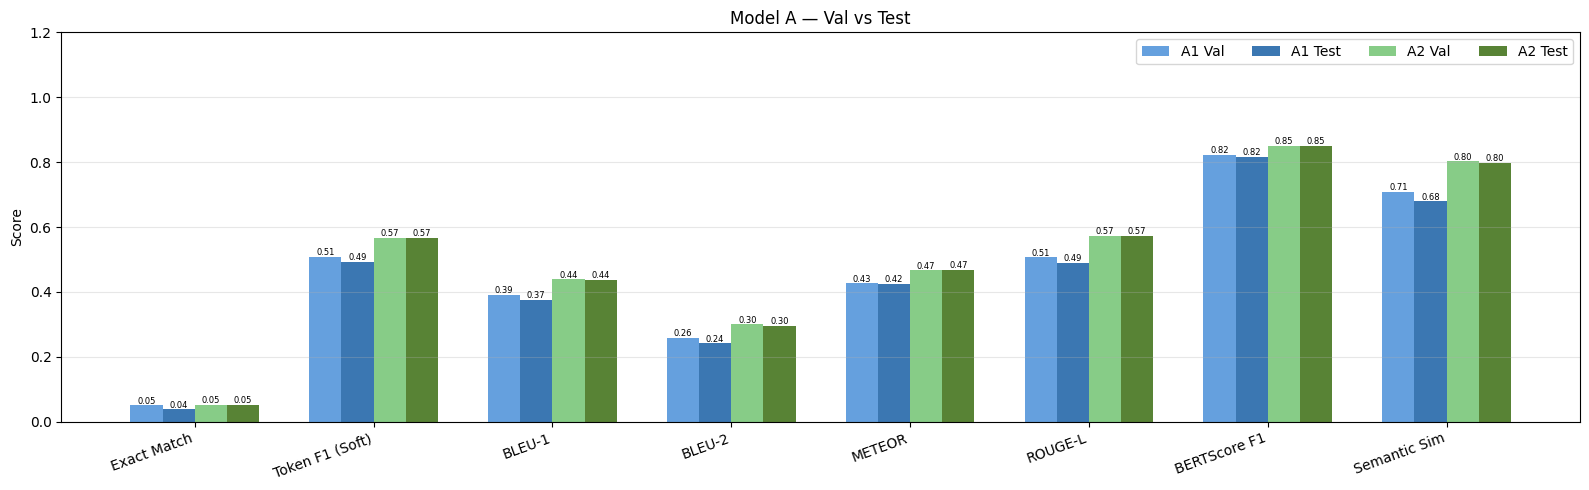

In [21]:
x = range(len(METRICS)); w = 0.18

fig, ax = plt.subplots(figsize=(16, 5))
for offset, (label, res) in enumerate([
    ("A1 Val",  res_val_A1), ("A1 Test", res_test_A1),
    ("A2 Val",  res_val_A2), ("A2 Test", res_test_A2),
]):
    vals = [res.get(m) or 0 for m in METRICS]
    offs = (offset - 1.5) * w
    bars = ax.bar([i + offs for i in x], vals, w, label=label, color=COLORS[label], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.2f}", ha="center", fontsize=6)

ax.set_xticks(list(x)); ax.set_xticklabels(METRICS, rotation=20, ha="right")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.2)
ax.set_title("Model A — Val vs Test"); ax.legend(ncol=4); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "results_A.png", dpi=150, bbox_inches="tight"); plt.show()


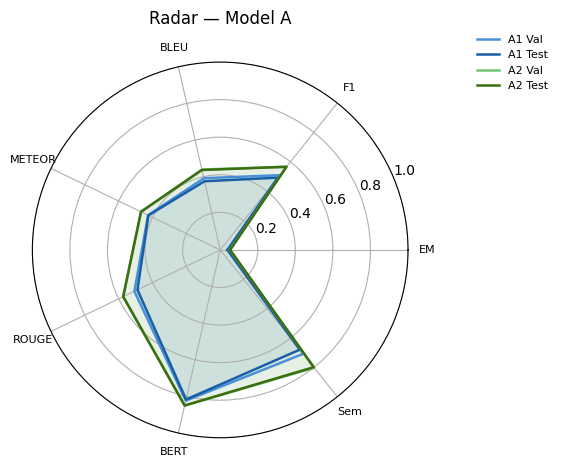

In [22]:
RMETRICS = [m for m in METRICS if m != "BLEU-2"]
angles = list(np.linspace(0, 2*np.pi, len(RMETRICS), endpoint=False)) + [0.0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for label, res in [
    ("A1 Val",  res_val_A1), ("A1 Test", res_test_A1),
    ("A2 Val",  res_val_A2), ("A2 Test", res_test_A2),
]:
    v = [res.get(m) or 0 for m in RMETRICS] + [res.get(RMETRICS[0]) or 0]
    ax.plot(angles, v, color=COLORS[label], lw=1.8, label=label)
    ax.fill(angles, v, color=COLORS[label], alpha=0.07)

ax.set_thetagrids(np.degrees(angles[:-1]),
                  ["EM", "F1", "BLEU", "METEOR", "ROUGE", "BERT", "Sem"], fontsize=8)
ax.set_ylim(0, 1); ax.set_title("Radar — Model A", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(FIG_DIR / "radar_A.png", dpi=150, bbox_inches="tight"); plt.show()


In [23]:
print(f"{'Question':<30} {'GT':<14} {'A1 Test':^14} {'A2 Test':^14}")
print("─" * 76)
for i in range(min(10, len(gts_test))):
    q  = qs_test[i][:28]
    gt = gts_test[i][:12]
    a1 = preds_A1_test[i][:12]
    a2 = preds_A2_test[i][:12]
    best = "A1" if token_f1(a1, gt) >= token_f1(a2, gt) else "A2"
    a1_disp = ("★" + a1) if best == "A1" else (" " + a1)
    a2_disp = ("★" + a2) if best == "A2" else (" " + a2)
    print(f"{q:<30} {gt:<14} {a1_disp:^14} {a2_disp:^14}")
print("★ = higher Token F1 for that sample")


Question                       GT                A1 Test        A2 Test    
────────────────────────────────────────────────────────────────────────────
Cho mình hỏi, một tô phở thư   năm lát         ba thành phầ   ★năm lát năm 
Bạn có thể cho biết, món này   khô             ★khô bột gạo   khô hai phần 
Món trong ảnh là gì?           phở            ★bánh phở phở   phở bánh phở 
Cho mình hỏi, người ta thườn   cả ngày Tết     ★sáng và tối    sáng và tối 
Vỏ bánh ướt nằm ở đâu nhỉ?     bên ngoài       bên trong dư  ★bên ngoài ng 
Có thịt trong món này không    có             ★có thành phầ    có trong có 
Theo bạn, một đĩa bánh ướt c   nhiều lớp      ★bốn loại phầ   ba thành phầ 
Theo bạn, món này có phải đồ   có              có sáng và t  ★có thành phầ 
Đây có phải món nước không n   không          ★không cơm tấ   không cả khô 
Theo bạn, món này có thành p   có             ★có thành phầ   có thành phầ 
★ = higher Token F1 for that sample


## 11. Đóng gói output để tải về

Gom checkpoints (best A1 + A2) + results JSON + figures vào 1 file zip rồi tạo link tải trực tiếp.
- **Trên Kaggle**: click vào link `vqa_a_output.zip` xuất hiện dưới cell → trình duyệt tự tải.
- **Trên local**: chạy cell vẫn ra link, click cũng được hoặc lấy file ở `WORK_ROOT/vqa_a_output.zip`.


In [28]:
import zipfile
from pathlib import Path

out_zip = Path("/kaggle/working/vqa_a_output.zip")
if out_zip.exists():
    out_zip.unlink()

SRC = [
    Path("/kaggle/working/results"),
    Path("/kaggle/working/checkpoints/"),
    Path("/kaggle/working/figures/")
]

n_files = 0
with zipfile.ZipFile(out_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for src in SRC:
        if not src.exists():
            print(f"[SKIP] {src} không tồn tại")
            continue
        for p in src.rglob("*"):
            if p.is_file():
                zf.write(p, p.relative_to("/kaggle/working"))
                n_files += 1

mb = out_zip.stat().st_size / 1024**2
print(f"✓ Done: {out_zip}  ({mb:.1f} MB, {n_files} files)")

✓ Done: /kaggle/working/vqa_a_output.zip  (847.6 MB, 6 files)
